In [15]:
using JLD2, StatFiles, DataFrames, TidierData, Plots, LaTeXStrings, Statistics, NonlinearSolve, LinearAlgebra
include("Globals.jl")
include("ProdFunc.jl");
include("PF_Transition.jl");
@load "ProductionFunction.jld2" p_star;

# Purpose of this Notebook
This notebook presents the methods used to compute, estimate and simulate the structural model. I use a three region example of the model to illustrate these points.

## Input Data
The dynamic hat algebra requires the input of some initial data; pre-period choice probabilities and time zero labor supplies. I construct this data from the CPS in 1995-1996 fore the pre-period choice probabilities. Using the 1995 stocks of migration by nativity from the CPS, I use these choice probabilities to generate labor supplies in 1996 which is my time zero.

The following cell illustrates what the full 52-region data looks like.

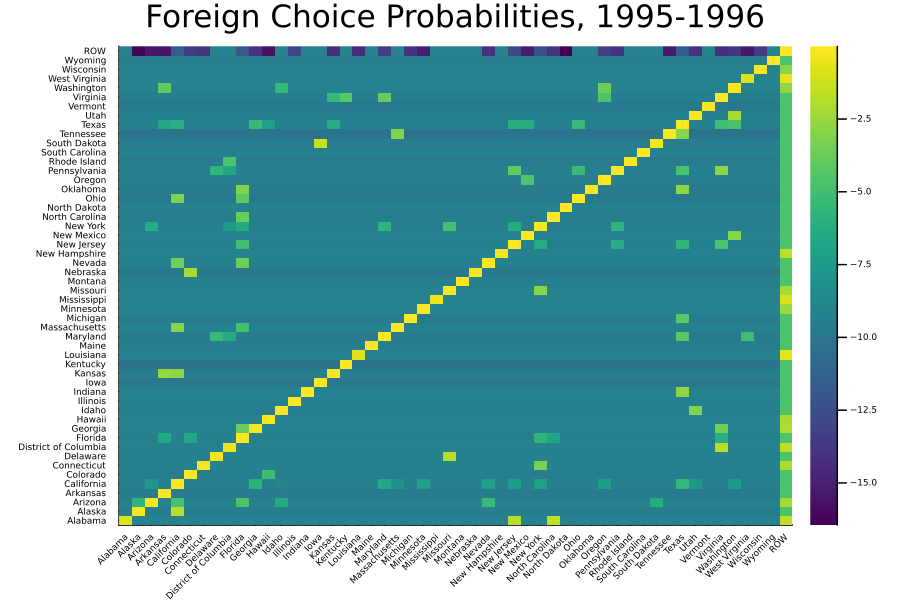

In [16]:
# Load in the initial data
Init_Data = DataFrame(load(joinpath(data, "PiMat.dta")));
ParamsAllRegions = Parameters();
(; Πᶠ₋, Πᵈ₋, N)     = ParamsAllRegions;
labels = Init_Data[:,:State];

heatmap(log.(Πᶠ₋), color = :viridis, dpi = 150, xrotation = 45, figsize = (10,6),
xtickfontsize = 4, ytickfontsize = 4, xticks = (1:N, labels), yticks = (1:N, labels), title = "Foreign Choice Probabilities, 1995-1996")

# Solving Sequential Equilibria with Dynamic Hat Algebra
As derived in the paper, given a sequence of changes to US-specific migration flows $\{\dot\mu_t\}_{t=0}^\infty$ an $\mathcal{L}\times\mathcal{L}$ matrix $\boldsymbol{\Pi}_{-1}$ of pre-period migration choice probabilities (just before time zero) and the initial supplies of domestic and foreign labor, $\{\boldsymbol{L}^D_0,\boldsymbol{L}^F_0\}$ we can use the methods of [Caliendo et. al. (2019)](https://onlinelibrary.wiley.com/doi/full/10.3982/ECTA13758) to solve for perfect foresight transitions toward a steady state. An equilibrium is the sequence of vectors and matrices (defined in the text) $\{\boldsymbol{\Pi}_{t}^D,\boldsymbol{\Pi}_t^F,\dot{\boldsymbol{u}}_{t+1}^D, \dot{\boldsymbol{u}}_{t+1}^F,\boldsymbol{w}^D_t, \boldsymbol{w}^F_t\}_{t=0}^\infty$ that solves
$$\begin{align}
\pi^n_{ll',t} &= \frac{(\dot{u}^n_{l',t+1})^\frac{\beta}{\nu^n}(\dot{\mu}_{ll',t})^\frac{1}{\nu^n}}{\sum_{k\in\mathcal{L}}\pi^n_{lk,t-1}(\dot{u}_{k,t+1}^n)^\frac{\beta}{\nu^n}(\dot{\mu}_{lk,t})^\frac{1}{\nu^n}}\pi^n_{ll',t-1}\\
\dot u^n_{l,t} &= \dot w_{l,t}\bigg(\sum_{l'\in\mathcal{L}}\pi^n_{ll',t-1}(\dot{u}_{l',t+1}^n)^\frac{\beta}{\nu^n}(\dot{\mu}_{ll',t})^\frac{1}{\nu^n}\bigg)^{\nu^n}\\
L^n_{l,t+1} &= \sum_{l'\in\mathcal{L}}\pi^n_{l'l,t}L_{l', t}^n\\
\bigg(\frac{w^D_t}{w^F_t}\bigg)^{-\frac{\rho}{1-\rho}} &= \bigg(\frac{L^D_{l,t}}{L^F_{l,t}}\bigg)^\rho\bigg(\frac{\int_\Omega\int_{\mathcal{T}_t(\omega)}(\alpha^Dz^D(\tau))^\frac{\rho}{1-\rho}d\tau dG(\omega)}{\int_\Omega\int_0^{\mathcal{T}_t(\omega)}(\omega\alpha^Fz^F(\tau))^\frac{\rho}{1-\rho}d\tau dG(\omega)}\bigg)^{-\rho} \\[2em]
\bigg(\frac{\theta}{r + \delta}\bigg)^\frac{\theta}{1-\theta}(1-\theta)Z_{l,t}L_{l,t} &= w^D_{l,t}L^D_{l,t} + w^F_{l,t}L^F_{l,t}
\end{align}$$
where I have plugged the capital expenditure expression into resource feasibility to rearrange in terms of the labor aggregate. Furthermore, under the parametric assumptions adopted in the empirical framework we have that
$$\begin{align*}
\int_\Omega\int_0^{\mathcal{T}_t(\omega)}(\omega\alpha^Fz^F(\tau))^\frac{\rho}{1-\rho}d\tau dG(\omega) &= (\alpha^F)^\frac{\rho}{1-\rho}\bigg(\frac{1-\rho}{\gamma^F\rho}\bigg)\bigg[\bigg(\frac{\alpha^Fw^D_{s,t}}{\alpha^Dw^F_{s,t}}\times\frac{1}{e^\Gamma}\bigg)^\frac{\rho\gamma^F}{(1-\rho)(\gamma^D-\gamma^F)}\mathbb{E}\omega^\frac{\rho\gamma^D}{(1-\rho)(\gamma^D-\gamma^F)} - \mathbb{E}\omega^\frac{\rho}{1-\rho}\bigg]\\
\int_\Omega\int_{\mathcal{T}_t(\omega)}(\alpha^Dz^D(\tau))^\frac{\rho}{1-\rho}d\tau dG(\omega) &= (\alpha^D)^\frac{\rho}{1-\rho}e^{\frac{\rho}{1-\rho}\Gamma}\frac{1-\rho}{\rho\gamma^D}\bigg[e^{\frac{\rho\gamma^D}{1-\rho}}- \bigg(\frac{\alpha^Fw^D_{s,t}}{\alpha^Dw^F_{s,t}}\times\frac{1}{e^\Gamma}\bigg)^\frac{\rho\gamma^D}{(1-\rho)(\gamma^D - \gamma^F)}\mathbb{E}\omega^\frac{\rho\gamma^D}{(1-\rho)(\gamma^D - \gamma^F)}\bigg]\\
\end{align*}$$
where
$$\mathbb{E}\omega^{\frac{\rho}{1-\rho}\frac{\gamma^D}{\gamma^D-\gamma^F}} = \frac{(\gamma^D - \gamma^F)(1-\rho)}{(\gamma^D-\gamma^F)(1-\rho) - \rho\gamma^D}\quad\text{and}\quad\mathbb{E}\omega^\frac{\rho}{1-\rho} = \frac{1-\rho}{1-2\rho}.$$

## No Shocks, 3-Region Economy
Let's suppose wages for the domestic and foreign born in ROW are exogenous. I will collapse the data down into three region for illustration; Alabama, a larger US region and ROW. We can see how the dynamic-hat works by supposing $\dot\mu_{t+1} = 1$ for all $t\geq0$. Under this assumption we are computing a transition path toward a new steady state when the US economy is not hit by any further US-Specific migration shocks.

In [17]:
# Select California, New York, and ROW
keep_origins = ["06", "36", "ROW"]   # CA, NY, ROW by FIPS
d_cols = ["pi_D_$s" for s in keep_origins]
f_cols = ["pi_F_$s" for s in keep_origins]

Init_Data_3 = filter(row -> row.Origin ∈ keep_origins, Init_Data)[:,
    vcat(["State", "Domestic_1996", "Foreign_1996"], d_cols, f_cols)]

# Restrict destination set to {CA, NY, ROW}: renormalize rows to sum to 1
for i in 1:nrow(Init_Data_3)
    dsum = sum(Float64(Init_Data_3[i, c]) for c in d_cols)
    fsum = sum(Float64(Init_Data_3[i, c]) for c in f_cols)
    for c in d_cols; Init_Data_3[i, c] /= dsum; end
    for c in f_cols; Init_Data_3[i, c] /= fsum; end
end

# Solve the transition
T0    = 20
p     = Parameters(p_star; Init_Data = Init_Data_3)
Soln0 = TransitSoln(p; T0 = T0)
Soln_noshock  = SolveSeqEq(no_shock(); p = p, init = Soln0)

	STATIC EQ location 1: done
	STATIC EQ location 2: done
****************** ITERATION 50 COMPLETE: Outer err = 0.7572051262822314 (α = 0.013886900853164085) *************************
	STATIC EQ location 1: done
	STATIC EQ location 2: done
****************** ITERATION 100 COMPLETE: Outer err = 0.3036835052311466 (α = 0.022838839049904636) *************************
	STATIC EQ location 1: done
	STATIC EQ location 2: done
****************** ITERATION 150 COMPLETE: Outer err = 0.06734090044326035 (α = 0.037561481475443886) *************************
	STATIC EQ location 1: done
	STATIC EQ location 2: done
****************** ITERATION 200 COMPLETE: Outer err = 0.0055352194661195675 (α = 0.061774807710114524) *************************
	STATIC EQ location 1: done
	STATIC EQ location 2: done
Extending T from 20 to 30 (ss_err = 0.006981223525469149)
	STATIC EQ location 1: done
	STATIC EQ location 2: done
****************** ITERATION 50 COMPLETE: Outer err = 0.009900081756001322 (α = 0.0122019003994

TransitSoln{Float64, Int64}([123.9881789302937 124.08074867225574 … 125.77656356514528 125.77654532963284; 122.46784886561491 122.51572519891542 … 124.03175051861966 124.03226166813994; 78.02207792207793 78.02207792207793 … 78.02207792207793 78.02207792207793], [16.482468715822854 16.26890856865607 … 13.214235170680787 13.214261222972459; 21.176217496853674 20.982828652940515 … 16.38117606875198 16.379995992184085; 5.305194805194804 5.305194805194804 … 5.305194805194804 5.305194805194804], [7.2020425 7.043329632722242 … 3.529878778458758 3.530478323794837; 4.4953235 4.455991448021075 … 1.6746020090064908 1.6729360864220904; 3.44725375 3.645298669256685 … 9.940138962534764 9.941205339783108], [3.076828 3.0976044676377197 … 2.4707775292216385 2.471186244607961; 1.101638125 1.1144072142077464 … 0.7252945994601798 0.7246891999472642; 5665.401344 5665.367798443155 … 5666.383737996338 5666.383934680474], [1.0071880948380896 1.0076710000500513 … 0.9999992527742775 1.0; 1.004646268552474 1.004

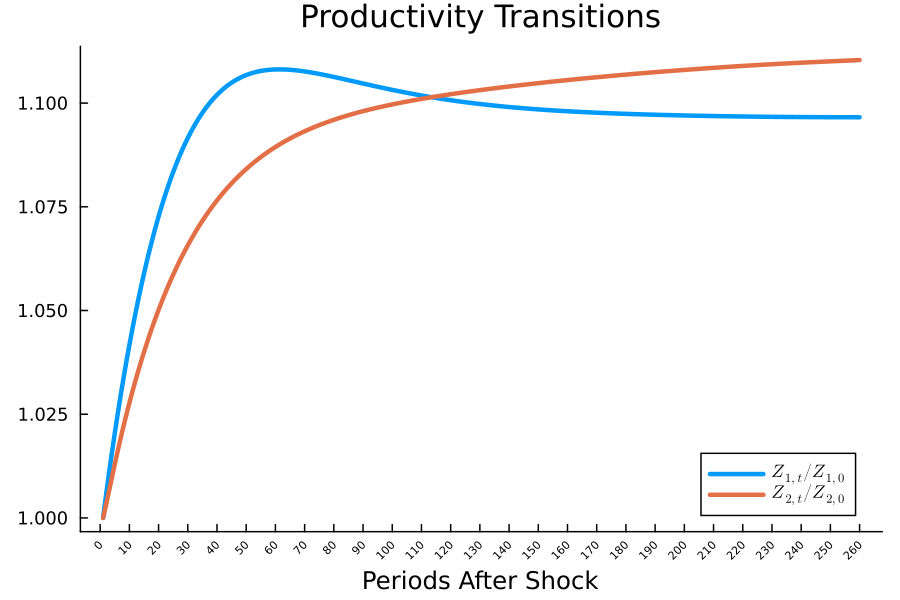

In [25]:
T_ns = Soln_noshock.T
Z_ns = ComputeZ(Soln_noshock; p = p)
plot(1:T_ns, Z_ns[1,:] / Z_ns[1,1],
grid = false, linewidth = 3., 
label = L"$Z_{1,t}/Z_{1,0}$", dpi = 150, xticks = 0:10:T_ns, title = "Productivity Transitions", 
xlabel = "Periods After Shock", figsize = (10,6), xrotation = 45, xtickfontsize = 5)
plot!(1:T_ns, Z[2,:] / Z[2,1], linewidth = 3., label = L"$Z_{2,t}/Z_{2,0}$")

## One Std. Dev. Reduction at Time Zero, 3-Region Economy
Now I hit the 1996 economy with a negative US-Specific migration cost shock.

In [34]:
# Solve the transition
T0    = 20
p     = Parameters(p_star; Init_Data = Init_Data_3)
Soln_ar1  = SolveSeqEq(ar1_shock(m₀ = 1., p = p); p = p, init = Soln0)

	STATIC EQ location 1: done
	STATIC EQ location 2: done
****************** ITERATION 50 COMPLETE: Outer err = 0.5786016374696397 (α = 0.015339777935796783) *************************
	STATIC EQ location 1: done
	STATIC EQ location 2: done
****************** ITERATION 100 COMPLETE: Outer err = 0.21177229356794847 (α = 0.025228286933230076) *************************
	STATIC EQ location 1: done
	STATIC EQ location 2: done
****************** ITERATION 150 COMPLETE: Outer err = 0.04018318861981962 (α = 0.04149124350099841) *************************
	STATIC EQ location 1: done
	STATIC EQ location 2: done
****************** ITERATION 200 COMPLETE: Outer err = 0.002541357712959158 (α = 0.06823781938961518) *************************
	STATIC EQ location 1: done
	STATIC EQ location 2: done
Extending T from 20 to 30 (ss_err = 0.006927955886988357)
	STATIC EQ location 1: done
	STATIC EQ location 2: done
****************** ITERATION 50 COMPLETE: Outer err = 0.00979967671047921 (α = 0.0122019003994796

TransitSoln{Float64, Int64}([123.9881789302937 124.09132888350824 … 125.7830355706715 125.7830382412012; 122.46784886561491 122.52642408233335 … 124.04032761333055 124.04085671612326; 78.02207792207793 78.02207792207793 … 78.02207792207793 78.02207792207793], [16.482468715822854 16.244890808825815 … 13.204996193464327 13.204992384213714; 21.176217496853674 20.94014517238544 … 16.361399368348817 16.360181125114217; 5.305194805194804 5.305194805194804 … 5.305194805194804 5.305194805194804], [7.2020425 7.051522888554302 … 3.547492458307604 3.548096002534873; 4.4953235 4.457260481338446 … 1.6842805655036008 1.682607719068852; 3.44725375 3.6358363801072513 … 9.912846726188794 9.913916028396303], [3.076828 3.1114199149234434 … 2.4870103736201994 2.4874351069866742; 1.101638125 1.11976178144314 … 0.7314496518972159 0.7308442288522785; 5665.401344 5665.348628428633 … 5666.361350099496 5666.36153078917], [1.0068120174839015 1.007571798243192 … 0.9999990708196899 1.0; 1.00457173156129 1.00492031

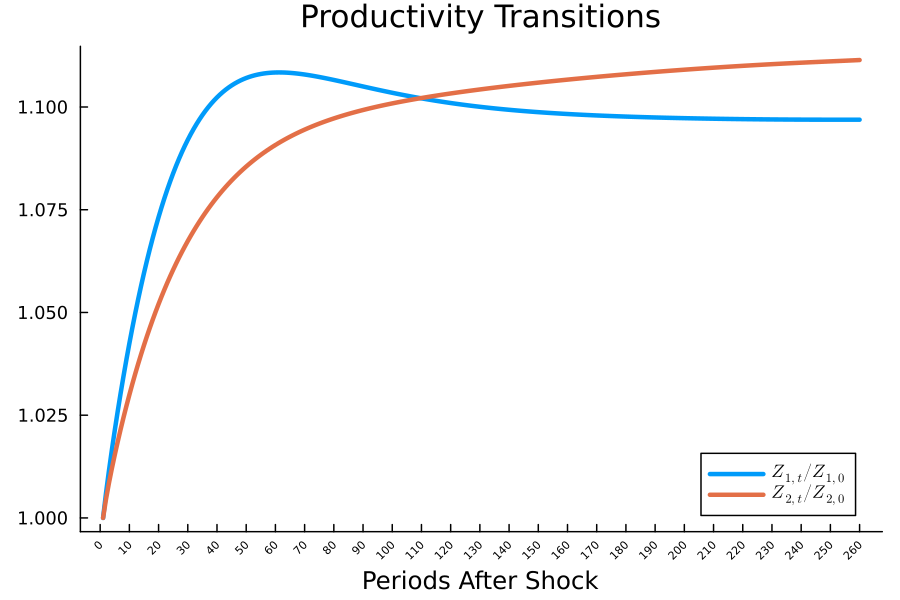

In [35]:
T_ar1 = Soln_ar1.T
Z_ar1 = ComputeZ(Soln_ar1; p = p)
plot(1:T_ar1, Z_ar1[1,:] / Z_ar1[1,1],
grid = false, linewidth = 3., 
label = L"$Z_{1,t}/Z_{1,0}$", dpi = 150, xticks = 0:10:T_ar1, title = "Productivity Transitions", 
xlabel = "Periods After Shock", figsize = (10,6), xrotation = 45, xtickfontsize = 5)
plot!(1:T_ar1, Z_ar1[2,:] / Z_ar1[2,1], linewidth = 3., label = L"$Z_{2,t}/Z_{2,0}$")

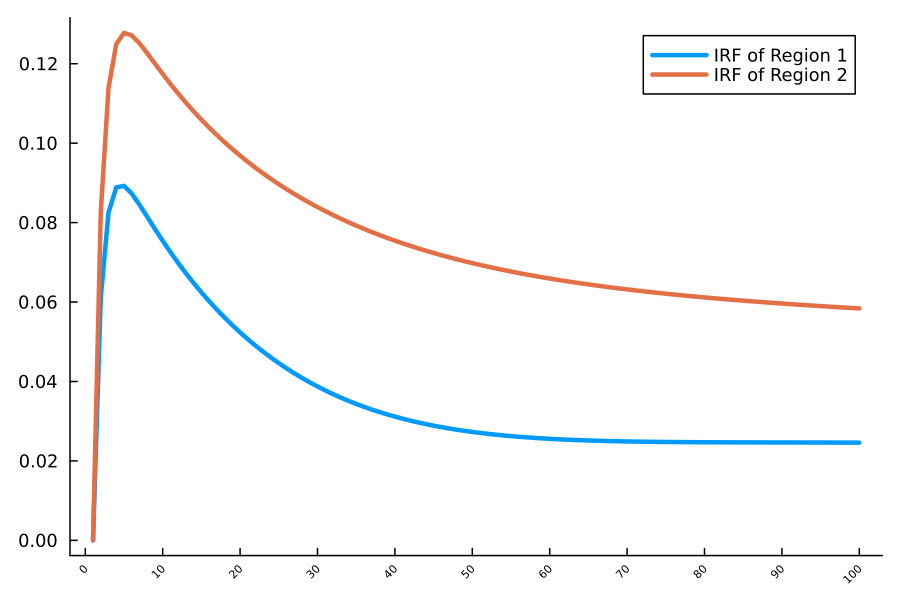

In [ ]:
# Plot the IRF
ΔZ = log.(Z_ar1 ./ Z_ns) * 100
plot(1:100, ΔZ[1,1:100], grid = false, linewidth = 3., dpi = 150, xticks = 0:10:100, figsize = (10,6), xrotation = 45, xtickfontsize = 5,
label = "IRF of Region 1")
plot!(1:100, ΔZ[2,1:100], label = "IRF of Region 2", linewidth = 3.)


# Solving for Counterfactual in One Fell Swoop
The above method of computing the IRF does not do the Dynamic Hat Algebra justice. Namely, we had to compute the sequential equilibrium two times. However, we can also write the equilibrium conditions as counterfactual deviations from the factual path.